<a href="https://colab.research.google.com/github/priyal6/General-llm/blob/main/matryoshka.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install -q -U sentence-transformers datasets scipy pandas matplotlib scikit-learn

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.3/62.3 kB 3.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 4.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.3/80.3 kB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 555.1/555.1 kB 24.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.3/35.3 MB 44.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 74.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 84.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 80.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.1/50.1 MB 10.5 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 3.0.3 which is incompatible.


In [ ]:
import time
import gc
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

from datasets import load_dataset
from scipy.stats import spearmanr
from sklearn.preprocessing import normalize
from sklearn.decomposition import PCA
from sentence_transformers import SentenceTransformer

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"

print("Device:", device)

if torch.cuda.is_available():
  print("GPU:", torch.cuda.get_device_name(0))

Device: cuda
GPU: Tesla T4


In [ ]:
dataset = load_dataset(
    "sentence-transformers/stsb",
    split="test"
)


print(dataset)
print(dataset.column_names)
print(dataset[0])

README.md:   0%|          | 0.00/1.50k [00:00<?, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/471k [00:00<?, ?B/s]

data/validation-00000-of-00001.parquet:   0%|          | 0.00/142k [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/108k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/5749 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/1500 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1379 [00:00<?, ? examples/s]

Dataset({
    features: ['sentence1', 'sentence2', 'score'],
    num_rows: 1379
})
['sentence1', 'sentence2', 'score']
{'sentence1': 'A girl is styling her hair.', 'sentence2': 'A girl is brushing her hair.', 'score': 0.5}


In [ ]:
sentences_1 = dataset["sentence1"]
sentences_2 = dataset["sentence2"]
gold_scores = np.asarray(dataset["score"], dtype=np.float32)


print("Number of sentence pairs:", len(sentences_1))
print("Example of sentence 1:", sentences_1[0])
print("Example of sentence 2:", sentences_2[0])
print("Human Score:", gold_scores[0])

Number of sentence pairs: 1379
Example of sentence 1: A girl is styling her hair.
Example of sentence 2: A girl is brushing her hair.
Human Score: 0.5


In [ ]:
NORMAL_MODEL_NAME = "sentence-transformers/all-mpnet-base-v2"
MATRYOSHKA_MODEL_NAME = "tomaarsen/mpnet-base-nli-matryoshka"

In [ ]:
normal_model = SentenceTransformer(
    NORMAL_MODEL_NAME,
    device=device
)


matryoshka_model = SentenceTransformer(
    MATRYOSHKA_MODEL_NAME,
    device=device
)

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/11.6k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/571 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/1.69k [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/711k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/1.01k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/321 [00:00<?, ?B/s]

In [ ]:
print(
    "Normal embedding dimension:",
    normal_model.get_sentence_embedding_dimension()
)

print(
    "Matryoshka embedding dimension:",
    matryoshka_model.get_sentence_embedding_dimension()
)

Normal embedding dimension: 768
Matryoshka embedding dimension: 768


/tmp/ipykernel_758/1815295848.py:3: FutureWarning: The `get_sentence_embedding_dimension` method has been renamed to `get_embedding_dimension`.
  normal_model.get_sentence_embedding_dimension()
/tmp/ipykernel_758/1815295848.py:8: FutureWarning: The `get_sentence_embedding_dimension` method has been renamed to `get_embedding_dimension`.
  matryoshka_model.get_sentence_embedding_dimension()


In [ ]:
all_sentences = list(dict.fromkeys(list(sentences_1) + list(sentences_2)))

print("Unique sentences:", len(all_sentences))

Unique sentences: 2552


In [ ]:
import pandas as pd

df = pd.DataFrame(all_sentences)

df.head(20)

,0
0,A girl is styling her hair.
1,A group of men play soccer on the beach.
2,One woman is measuring another woman's ankle.
3,A man is cutting up a cucumber.
4,A man is playing a harp.
5,A woman is cutting onions.
6,A man is riding an electric bicycle.
7,A man is playing the drums.
8,A man is playing guitar.
9,A man is playing a guitar.


In [ ]:
def encode_sentences(model, sentences, batch_size=64):
  start = time.perf_counter()

  embeddings = model.encode(
      sentences,
      batch_size=batch_size,
      convert_to_numpy=True,
      normalize_embeddings=False,
      show_progress_bar=True
  )

  elapsed = time.perf_counter() - start

  return embeddings.astype(np.float32), elapsed

In [ ]:
normal_full_embeddings, normal_encoding_time = encode_sentences(
    normal_model,
    all_sentences
)

matryoshka_full_embeddings, matryoshka_encoding_time = encode_sentences(
    matryoshka_model,
    all_sentences
)

Batches:   0%|          | 0/40 [00:00<?, ?it/s]

Batches:   0%|          | 0/40 [00:00<?, ?it/s]

In [ ]:
print("Normal embedding shape:", normal_full_embeddings.shape)
print("Matryoshka embedding shape:", matryoshka_full_embeddings.shape)

print(f"Normal encoding time: {normal_encoding_time:.3f} seconds")
print(f"Matryoshka encoding time: {matryoshka_encoding_time:.3f} seconds")

Normal embedding shape: (2552, 768)
Matryoshka embedding shape: (2552, 768)
Normal encoding time: 3.636 seconds
Matryoshka encoding time: 2.879 seconds


In [ ]:
sentence_to_index = {
    sentence: index
    for index, sentence in enumerate(all_sentences)
}

In [ ]:
indices_1 = np.array(
    [sentence_to_index[sentence] for sentence in sentences_1]
)

indices_2 = np.array(
    [sentence_to_index[sentence] for sentence in sentences_2]
)

In [ ]:
def truncate_and_normalize(embeddings, dimension):
  truncated = embeddings[:, :dimension]

  truncated = normalize(
      truncated,
      norm="l2",
      axis=1
  )

  return truncated.astype(np.float32)

In [ ]:
def evaluate_sts(
    full_embeddings,
    dimension,
    sentence1_indices,
    sentence2_indices,
    labels
):

  embeddings = truncate_and_normalize(
      full_embeddings,
      dimension
  )

  embeddings_1 = embeddings[sentence1_indices]
  embeddings_2 = embeddings[sentence2_indices]

  cosine_scores = np.sum(
      embeddings_1 * embeddings_2,
      axis=1
  )

  correlation = spearmanr(cosine_scores, labels).statistic

  return correlation

In [ ]:
dimensions = [768, 512, 256, 128, 64, 32]

In [ ]:
results = []

for dimension in dimensions:
  normal_score = evaluate_sts(
      normal_full_embeddings,
      dimension,
      indices_1,
      indices_2,
      gold_scores
  )

  matryoshka_score = evaluate_sts(
      matryoshka_full_embeddings,
        dimension,
        indices_1,
        indices_2,
        gold_scores

  )

  results.append(
      {
          "dimension": dimension,
          "normal_spearman": normal_score,
          "matryoshka_spearman": matryoshka_score
      }
  )

results_df = pd.DataFrame(results)
results_df

,dimension,normal_spearman,matryoshka_spearman
0,768,0.834222,0.868115
1,512,0.833817,0.867613
2,256,0.827374,0.866680
3,128,0.816611,0.862061
4,64,0.800803,0.854022
5,32,0.777406,0.823940


In [ ]:
normal_full_score = results_df.loc[
    results_df["dimension"] == 768,
    "normal_spearman"
].iloc[0]

matryoshka_full_score = results_df.loc[
    results_df["dimension"] == 768,
    "matryoshka_spearman"
].iloc[0]

In [ ]:
results_df["normal_retention_pct"] = (
    results_df["normal_spearman"]
    / normal_full_score
    * 100
)

results_df["matryoshka_retention_pct"] = (
    results_df["matryoshka_spearman"]
    / matryoshka_full_score
    * 100
)

results_df.round(4)

,dimension,normal_spearman,matryoshka_spearman,normal_retention_pct,matryoshka_retention_pct
0,768,0.8342,0.8681,100.0000,100.0000
1,512,0.8338,0.8676,99.9516,99.9421
2,256,0.8274,0.8667,99.1792,99.8347
3,128,0.8166,0.8621,97.8890,99.3027
4,64,0.8008,0.8540,95.9940,98.3766
5,32,0.7774,0.8239,93.1894,94.9114


performance at reduced dimension/
performance at full dimension * 100

In [ ]:
plot_df = results_df.sort_values("dimension")

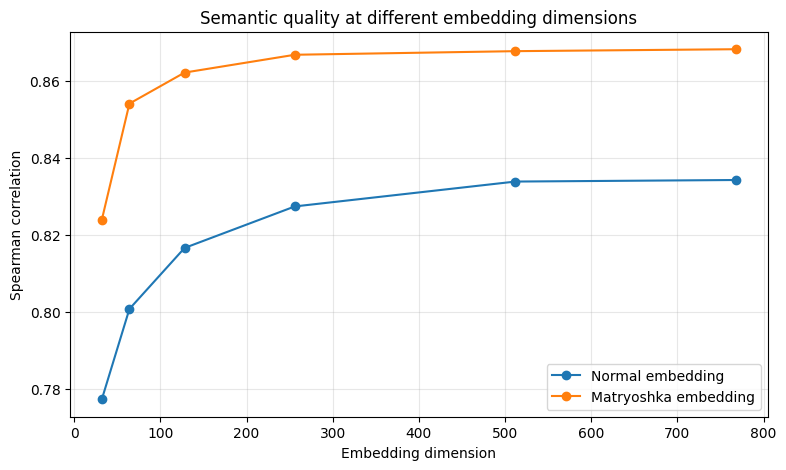

In [ ]:
plt.figure(figsize=(9,5))

plt.plot(
    plot_df["dimension"],
    plot_df["normal_spearman"],
    marker="o",
    label="Normal embedding"
)

plt.plot(
    plot_df["dimension"],
    plot_df["matryoshka_spearman"],
    marker="o",
    label="Matryoshka embedding"
)


plt.xlabel("Embedding dimension")
plt.ylabel("Spearman correlation")
plt.title("Semantic quality at different embedding dimensions")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

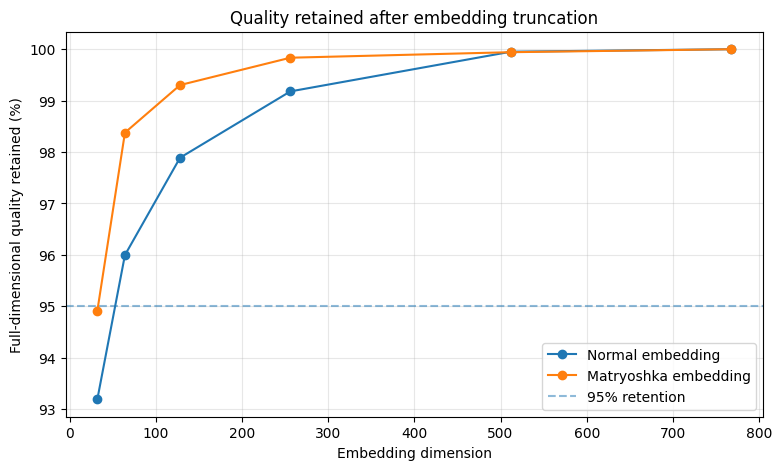

In [ ]:
plt.figure(figsize=(9,5))

plt.plot(
    plot_df["dimension"],
    plot_df["normal_retention_pct"],
    marker="o",
    label="Normal embedding"
)

plt.plot(
    plot_df["dimension"],
    plot_df["matryoshka_retention_pct"],
    marker="o",
    label="Matryoshka embedding"

)

plt.axhline(
    95,
    linestyle="--",
    alpha=0.5,
    label="95% retention"
)

plt.xlabel("Embedding dimension")
plt.ylabel("Full-dimensional quality retained (%)")
plt.title("Quality retained after embedding truncation")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

storage of vectors

In [ ]:
def embedding_memory_mb(
    number_of_vectors,
    dimension,
    bytes_per_value=4
):
  return (
      number_of_vectors
      * dimension
      * bytes_per_value
      / 1024**2
  )

In [ ]:
NUMBER_OF_PRODUCTION_VECTOR = 1_000_000

storage_results = []

for dimension in dimensions:
  memory_mb = embedding_memory_mb(
      NUMBER_OF_PRODUCTION_VECTOR,
      dimension
  )

  storage_results.append(
      {
            "dimension": dimension,
            "memory_mb": memory_mb,
            "memory_gb": memory_mb / 1024
      }
  )
storage_df = pd.DataFrame(storage_results)

storage_df.round(3)

,dimension,memory_mb,memory_gb
0,768,2929.688,2.861
1,512,1953.125,1.907
2,256,976.562,0.954
3,128,488.281,0.477
4,64,244.141,0.238
5,32,122.070,0.119


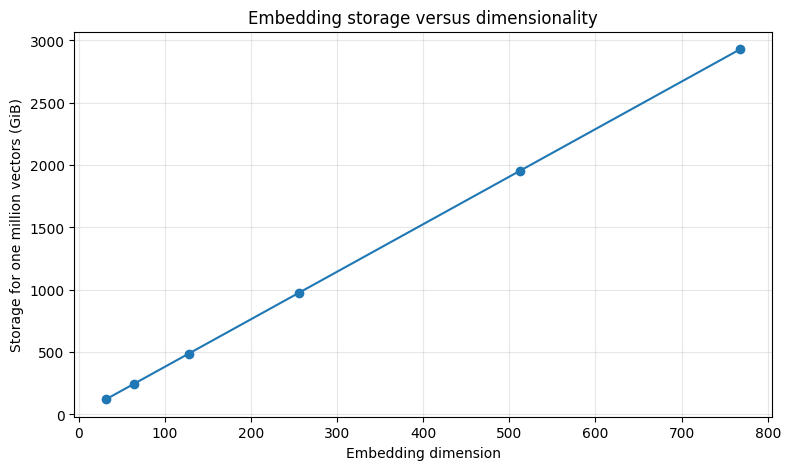

In [ ]:
storage_plot_df = storage_df.sort_values("dimension")

plt.figure(figsize=(9,5))

plt.plot(
    storage_plot_df["dimension"],
    storage_plot_df["memory_mb"],
    marker="o"
)

plt.xlabel("Embedding dimension")
plt.ylabel("Storage for one million vectors (GiB)")
plt.title("Embedding storage versus dimensionality")
plt.grid(alpha=0.3)
plt.show()